In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report
import tensorflow as tf
import pickle
import os

print("Текущая папка:", os.getcwd())

model = tf.keras.models.load_model('../../models/lstm_model.keras')
with open('../../data/label_encoder.pkl', 'rb') as f:
    le = pickle.load(f)

print("Модель загружена!")
print(f"Классы: {list(le.classes_)}")

Текущая папка: /Users/maxkumov/Desktop/smart-home-thesis/maksim/notebooks


2026-04-16 19:39:26.119832: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M2
2026-04-16 19:39:26.120218: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 8.00 GB
2026-04-16 19:39:26.120222: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 2.67 GB
2026-04-16 19:39:26.120810: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-04-16 19:39:26.121216: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Модель загружена!
Классы: ['Bathroom', 'Bedroom', 'DiningRoom', 'GuestRoom', 'Kitchen', 'LivingRoom', 'LoungeChair', 'OtherRoom', 'OutsideDoor', 'WorkArea']


In [4]:
# Ячейка 2 - Функция для тестирования на любом датасете
def test_on_dataset(filepath, dataset_name):
    print(f"\n{'='*50}")
    print(f"Тестируем на {dataset_name}")
    print(f"{'='*50}")
    
    # Загружаем данные
    df = pd.read_csv(filepath, header=None, sep=',',
                     names=['date', 'time', 'sensor', 'value'])
    df['datetime'] = pd.to_datetime(df['date'] + ' ' + df['time'], 
                                     format='mixed', errors='coerce')
    df = df.dropna(subset=['datetime'])
    df = df[df['value'] == 'ON'].copy()
    
    # Проверяем какие сенсоры есть в датасете
    sensors_in_data = set(df['sensor'].unique())
    sensors_in_model = set(le.classes_)
    common_sensors = sensors_in_data & sensors_in_model
    
    print(f"Сенсоров в датасете: {sensors_in_data}")
    print(f"Общих с моделью: {common_sensors}")
    
    # Фильтруем только общие сенсоры
    df = df[df['sensor'].isin(common_sensors)].copy()
    
    df['hour'] = df['datetime'].dt.hour
    df['minute'] = df['datetime'].dt.minute
    df['weekday'] = df['datetime'].dt.weekday
    df['is_weekend'] = (df['weekday'] >= 5).astype(int)
    df['sensor_id'] = le.transform(df['sensor'])
    
    # Создаём последовательности
    SEQUENCE_LENGTH = 10
    features = ['sensor_id', 'hour', 'minute', 'weekday', 'is_weekend']
    data = df[features].values
    
    X, y = [], []
    for i in range(len(data) - SEQUENCE_LENGTH):
        X.append(data[i:i+SEQUENCE_LENGTH])
        y.append(data[i+SEQUENCE_LENGTH][0])
    
    X = np.array(X[:10000])
    y = np.array(y[:10000])
    
    # Предсказываем
    y_pred = model.predict(X, verbose=0).argmax(axis=1)
    acc = accuracy_score(y, y_pred)
    
    print(f"\nТочность на {dataset_name}: {acc:.2%}")
    print(classification_report(y, y_pred, 
                                target_names=le.classes_,
                                zero_division=0))
    return acc

# Тестируем
acc_milan = test_on_dataset('../../data/milan/milan.csv', 'Milan')
acc_cairo = test_on_dataset('../../data/cairo/cairo.csv', 'Cairo')


Тестируем на Milan
Сенсоров в датасете: {'Bathroom', 'LoungeChair', 'OtherRoom', 'LivingRoom', 'Bedroom', 'DiningRoom', 'Kitchen', 'OutsideDoor', 'WorkArea'}
Общих с моделью: {'Bathroom', 'LoungeChair', 'OtherRoom', 'LivingRoom', 'Bedroom', 'DiningRoom', 'Kitchen', 'OutsideDoor', 'WorkArea'}


2026-04-16 19:40:03.322141: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.



Точность на Milan: 69.96%
              precision    recall  f1-score   support

    Bathroom       0.66      0.66      0.66      1098
     Bedroom       0.66      0.75      0.70      1123
  DiningRoom       0.36      0.03      0.06       312
   GuestRoom       0.00      0.00      0.00         0
     Kitchen       0.90      0.94      0.92      3605
  LivingRoom       0.26      0.34      0.29       913
 LoungeChair       0.81      0.73      0.77      1838
   OtherRoom       0.00      0.00      0.00        11
 OutsideDoor       0.00      0.00      0.00       454
    WorkArea       0.45      0.62      0.52       646

    accuracy                           0.70     10000
   macro avg       0.41      0.41      0.39     10000
weighted avg       0.68      0.70      0.69     10000


Тестируем на Cairo
Сенсоров в датасете: {'OtherRoom', 'LivingRoom', 'Bedroom', 'GuestRoom', 'Kitchen', 'Hall', 'OutsideDoor', 'WorkArea'}
Общих с моделью: {'OtherRoom', 'LivingRoom', 'Bedroom', 'GuestRoom', 'Kitch

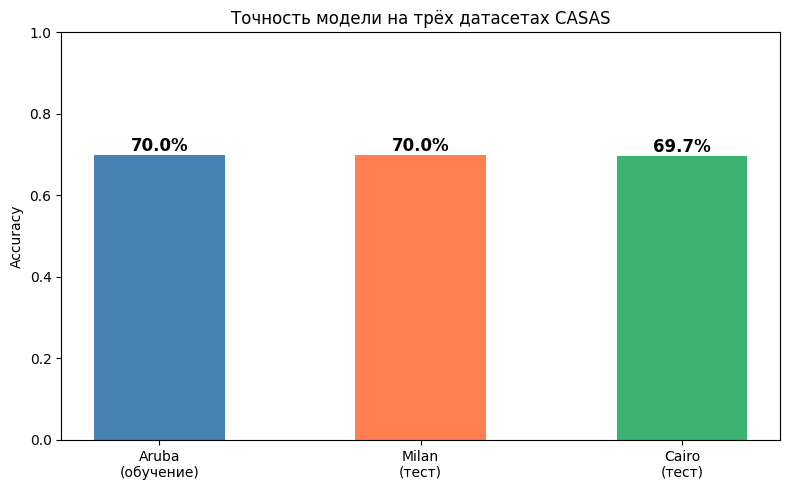

In [5]:
# Ячейка 3 - Сравнительный график
datasets = ['Aruba\n(обучение)', 'Milan\n(тест)', 'Cairo\n(тест)']
accuracies = [0.70, acc_milan, acc_cairo]
colors = ['steelblue', 'coral', 'mediumseagreen']

plt.figure(figsize=(8, 5))
bars = plt.bar(datasets, accuracies, color=colors, width=0.5)
plt.ylim(0, 1)
plt.title('Точность модели на трёх датасетах CASAS')
plt.ylabel('Accuracy')

for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{acc:.1%}', ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()